In [1]:
# ===== 0. 基础设置 =====
import os
import sys
import json
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
torch.set_grad_enabled(False)

print("REPO_ROOT =", REPO_ROOT)
print("CUDA available =", torch.cuda.is_available())

ModuleNotFoundError: No module named 'pandas'

## 1. 配置区

把下面的路径改成你要分析的两个实验目录。

通常你会至少跑两个对象：
- `MMRL`
- `BayesMMRL`

你可以先单独分析一个方法，再跑“对比单元格”。

In [2]:
# ===== 1. 用户配置 =====

DATA_ROOT = "DATASETS"
DATASET_CONFIG = "configs/datasets/caltech101.yaml"
PROTOCOL_CONFIG = "configs/protocols/fs.yaml"
RUNTIME_CONFIG = "configs/runtime/default.yaml"

MMRL_CFG = {
    "method": "MMRL",
    "method_config_file": "configs/methods/mmrl.yaml",
    "protocol": "FS",
    "exec_mode": "online",
    "seed": 1,
    "num_shots": 16,
    "subsample_classes": "all",
    "backbone": "ViT-B/16",
    "dataset_name": "caltech101",
    "model_dir": "output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    "load_epoch": None,
}

BAYES_CFG = {
    "method": "BayesMMRL",
    "method_config_file": "configs/methods/bayesmmrl.yaml",
    "protocol": "FS",
    "exec_mode": "online",
    "seed": 1,
    "num_shots": 16,
    "subsample_classes": "all",
    "backbone": "ViT-B/16",
    "dataset_name": "caltech101",
    "model_dir": "output_refactor/BayesMMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1",
    "load_epoch": None,
}

MAX_BATCHES = -1
MC_SAMPLES = 8

## 2. 构建 trainer / 加载模型

这里直接复用你仓库现有的训练器和配置系统，不另写脚本。

In [3]:
# ===== 2. 加载仓库 trainer =====
from core.config import setup_cfg
from core.utils import import_optional_modules
from dassl.engine import build_trainer
from dassl.utils import set_random_seed


def build_args(method_cfg: dict):
    class Args:
        pass

    args = Args()
    args.root = DATA_ROOT
    args.output_dir = ""
    args.dataset_config_file = DATASET_CONFIG
    args.method_config_file = method_cfg["method_config_file"]
    args.protocol_config_file = PROTOCOL_CONFIG
    args.runtime_config_file = RUNTIME_CONFIG
    args.exp_config = ""
    args.method = method_cfg["method"]
    args.protocol = method_cfg["protocol"]
    args.exec_mode = method_cfg["exec_mode"]
    args.seed = method_cfg["seed"]
    args.trainer = "RefactorRunner"
    args.eval_only = True
    args.model_dir = method_cfg["model_dir"]
    args.load_epoch = method_cfg["load_epoch"]
    args.no_train = True
    args.opts = [
        "DATASET.NUM_SHOTS", str(method_cfg.get("num_shots", 1)),
        "DATASET.SUBSAMPLE_CLASSES", method_cfg.get("subsample_classes", "all"),
        "MODEL.BACKBONE.NAME", method_cfg.get("backbone", "ViT-B/16"),
    ]
    return args



def build_repo_trainer(method_cfg: dict):
    import_optional_modules([
        "datasets.oxford_pets", "datasets.oxford_flowers", "datasets.fgvc_aircraft",
        "datasets.dtd", "datasets.eurosat", "datasets.stanford_cars", "datasets.food101",
        "datasets.sun397", "datasets.caltech101", "datasets.ucf101", "datasets.imagenet",
        "datasets.imagenetv2", "datasets.imagenet_sketch", "datasets.imagenet_a", "datasets.imagenet_r",
    ])
    importlib.import_module("trainers.refactor_runner")

    args = build_args(method_cfg)
    cfg = setup_cfg(args)
    if cfg.SEED >= 0:
        set_random_seed(cfg.SEED)

    trainer = build_trainer(cfg)
    trainer.load_model(method_cfg["model_dir"], epoch=method_cfg["load_epoch"])
    trainer.set_model_mode("eval")
    return cfg, trainer

## 3. 核心 helper

In [4]:
# ===== 3. helper functions =====
from evaluation.protocol_router import select_eval_logits

def cosine_matrix(x: torch.Tensor):
    x = F.normalize(x.float(), dim=1)
    return x @ x.t()

def pairwise_cosine_summary(x: torch.Tensor):
    sim = cosine_matrix(x)
    n = sim.size(0)
    mask = ~torch.eye(n, dtype=torch.bool, device=sim.device)
    vals = sim[mask]
    return {
        "mean": float(vals.mean().item()) if vals.numel() else 0.0,
        "std": float(vals.std().item()) if vals.numel() else 0.0,
        "min": float(vals.min().item()) if vals.numel() else 0.0,
        "max": float(vals.max().item()) if vals.numel() else 0.0,
    }

def svd_summary(x: torch.Tensor):
    s = torch.linalg.svdvals(x.float()).cpu()
    p = (s ** 2) / (s ** 2).sum().clamp_min(1e-12)
    effective_rank = torch.exp(-(p * torch.log(p.clamp_min(1e-12))).sum())
    return {
        "singular_values": s.numpy(),
        "effective_rank": float(effective_rank.item()),
    }

def top2_margin(logits: torch.Tensor):
    vals = torch.topk(logits, k=2, dim=1).values
    return vals[:, 0] - vals[:, 1]

def numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def show_heatmap(mat, title, xlabel="", ylabel=""):
    plt.figure()
    plt.imshow(numpy(mat), aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def show_bar(values, title, xlabel="", ylabel=""):
    plt.figure()
    plt.bar(np.arange(len(values)), numpy(values))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def show_line(values, title, xlabel="", ylabel=""):
    plt.figure()
    plt.plot(np.arange(len(values)), numpy(values), marker="o")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def show_hist(values, title, xlabel="", bins=40):
    plt.figure()
    plt.hist(numpy(values), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.show()

def show_scatter(x, y, title, xlabel="", ylabel="", alpha=0.4):
    plt.figure()
    plt.scatter(numpy(x), numpy(y), alpha=alpha, s=10)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def mean_std(x):
    x = numpy(x).reshape(-1)
    return float(x.mean()), float(x.std())

def accuracy_from_logits(logits, labels):
    pred = logits.argmax(dim=1)
    return float((pred == labels).float().mean().item() * 100.0)

## 4. 分析 `R`

In [5]:
# ===== 4. R analysis =====

def analyze_R(method, mc_samples=8):
    learner = method.model.representation_learner
    result = {"method_name": method.method_name}

    if method.method_name == "MMRL":
        R = learner.compound_rep_tokens.detach().cpu()
        rep_text, rep_visual = learner()
        rep_text = torch.stack([x.detach().cpu() for x in rep_text], dim=0)
        rep_visual = torch.stack([x.detach().cpu() for x in rep_visual], dim=0)

        result["R"] = {
            "tensor": R,
            "fro_norm": float(R.norm().item()),
            "token_norms": R.norm(dim=1),
            "pairwise_cosine": cosine_matrix(R),
            "pairwise_cosine_summary": pairwise_cosine_summary(R),
            "svd": svd_summary(R),
        }
        result["projected_text"] = rep_text
        result["projected_visual"] = rep_visual
        return result

    if method.method_name == "BayesMMRL":
        mu = learner.posterior_mean.detach().cpu()
        sigma = float(learner.posterior_sigma().detach().cpu().item())

        rep_text_mean, rep_visual_mean = learner.project_mean_tokens()
        rep_text_mean = torch.stack([x.detach().cpu() for x in rep_text_mean], dim=0)
        rep_visual_mean = torch.stack([x.detach().cpu() for x in rep_visual_mean], dim=0)

        sample_R = []
        sample_text_norm = []
        sample_visual_norm = []

        for _ in range(mc_samples):
            rep_text_s, rep_visual_s = learner.project_sample_tokens()
            rep_text_s = torch.stack([x.detach().cpu() for x in rep_text_s], dim=0)
            rep_visual_s = torch.stack([x.detach().cpu() for x in rep_visual_s], dim=0)

            eps = torch.randn_like(mu)
            sample_R.append(mu + sigma * eps)
            sample_text_norm.append(rep_text_s.norm(dim=2).mean())
            sample_visual_norm.append(rep_visual_s.norm(dim=2).mean())

        sample_R = torch.stack(sample_R, dim=0)

        result["R_mean"] = {
            "tensor": mu,
            "fro_norm": float(mu.norm().item()),
            "token_norms": mu.norm(dim=1),
            "pairwise_cosine": cosine_matrix(mu),
            "pairwise_cosine_summary": pairwise_cosine_summary(mu),
            "svd": svd_summary(mu),
        }
        result["posterior"] = {
            "sigma_scalar": sigma,
            "sample_R_std_per_entry": sample_R.std(dim=0),
            "sample_R_std_mean": float(sample_R.std(dim=0).mean().item()),
            "sample_R_std_max": float(sample_R.std(dim=0).max().item()),
            "sample_projected_text_norm_mean": float(torch.stack(sample_text_norm).mean().item()),
            "sample_projected_visual_norm_mean": float(torch.stack(sample_visual_norm).mean().item()),
        }
        result["projected_text_mean"] = rep_text_mean
        result["projected_visual_mean"] = rep_visual_mean
        return result

    raise ValueError(f"Unsupported method {method.method_name}")

In [6]:
# 运行 R 分析
mmrl_cfg, mmrl_trainer = build_repo_trainer(MMRL_CFG)
bayes_cfg, bayes_trainer = build_repo_trainer(BAYES_CFG)

mmrl_R = analyze_R(mmrl_trainer.method, mc_samples=MC_SAMPLES)
bayes_R = analyze_R(bayes_trainer.method, mc_samples=MC_SAMPLES)

print("MMRL pairwise cosine summary:", mmrl_R["R"]["pairwise_cosine_summary"])
print("MMRL effective rank:", mmrl_R["R"]["svd"]["effective_rank"])
print("Bayes sigma:", bayes_R["posterior"]["sigma_scalar"])
print("Bayes pairwise cosine summary:", bayes_R["R_mean"]["pairwise_cosine_summary"])
print("Bayes effective rank:", bayes_R["R_mean"]["svd"]["effective_rank"])

Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     2,465
---------  ----------
[MMRLMethod] trainable params: {'representation_learner.compound_rep_tokens_r2vproj.0.weight', 'representation_learner.compound_rep_tokens_r2tproj.2.bias', 'repr

/root/miniconda3/envs/mmrl/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/root/autodl-tmp/MMRL/trainers/refactor_runner.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = GradScaler() if prec == "amp" else None
/root/autodl-tmp/Dassl.pytorch/dassl/utils/torchtools.py:102: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpic

Loading weights to refactor_model from "output_refactor/MMRL/FS/fewshot_train/caltech101/shots_16/ViT-B-16/default/seed1/refactor_model/model.pth.tar-50" (epoch = 50)
Loading trainer: RefactorRunner
Loading dataset: Caltech101
Reading split from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_zhou_Caltech101.json
Loading preprocessed few-shot data from /root/autodl-tmp/MMRL/DATASETS/caltech-101/split_fewshot/shot_16-seed_1.pkl
Building transform_train
+ random resized crop (size=(224, 224), scale=(0.5, 1))
+ random flip
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
Building transform_test
+ resize the smaller edge to 224
+ 224x224 center crop
+ to torch tensor of range [0, 1]
+ normalization (mean=[0.48145466, 0.4578275, 0.40821073], std=[0.26862954, 0.26130258, 0.27577711])
---------  ----------
Dataset    Caltech101
# classes  100
# train_x  1,600
# val      400
# test     2,465
---------  -----

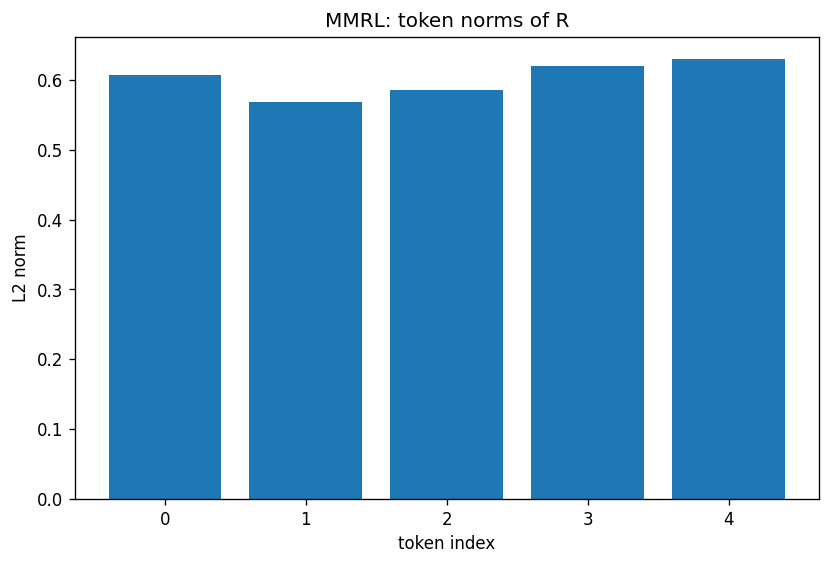

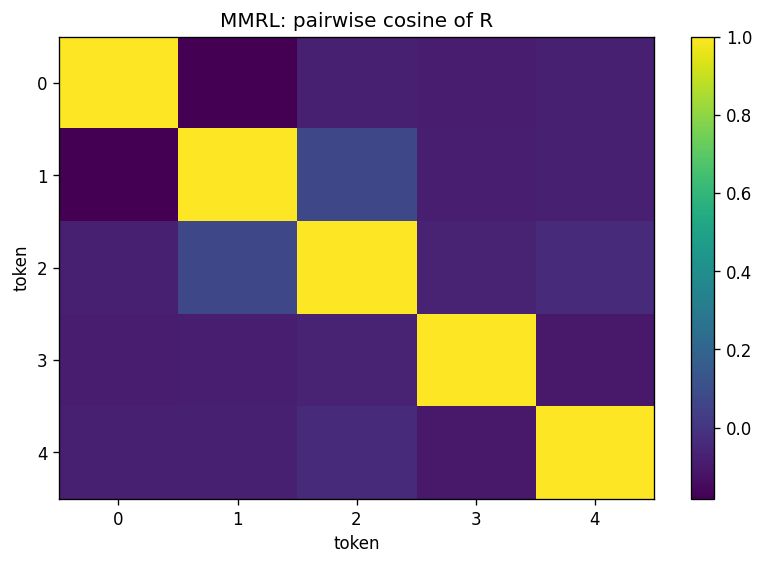

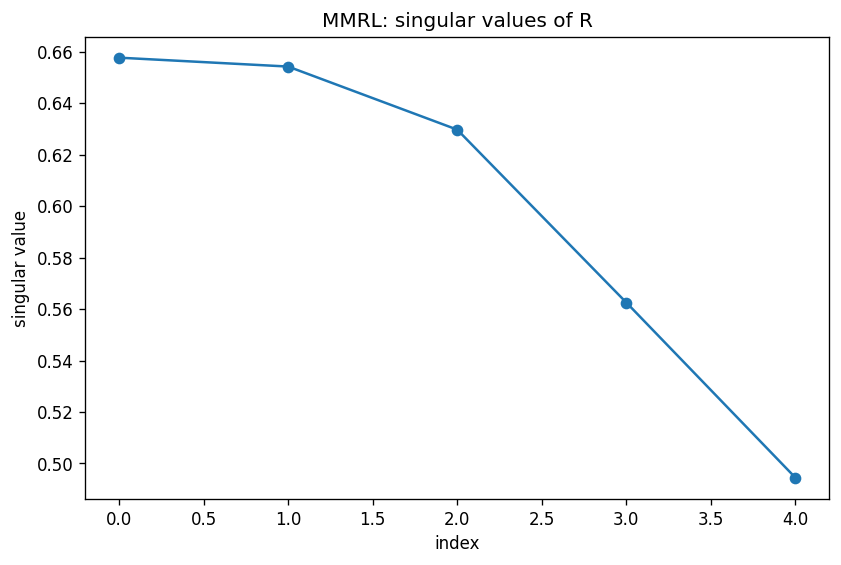

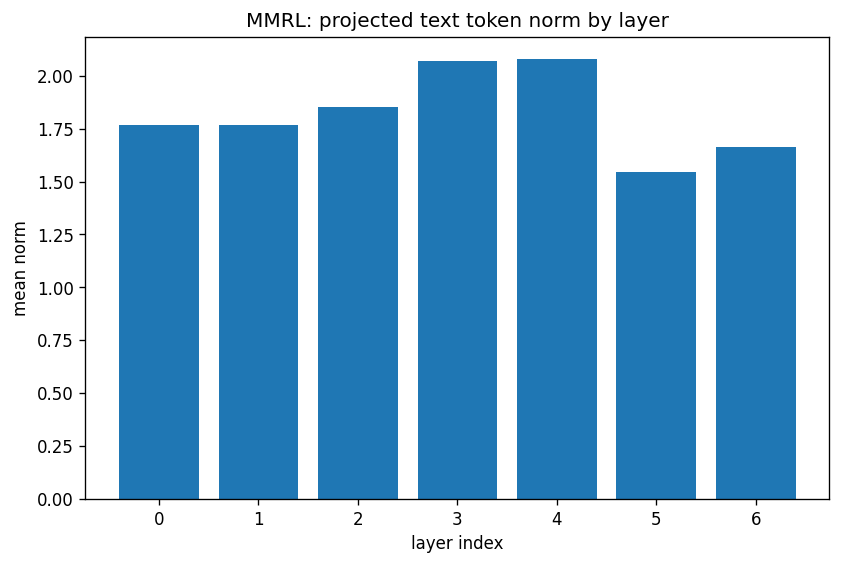

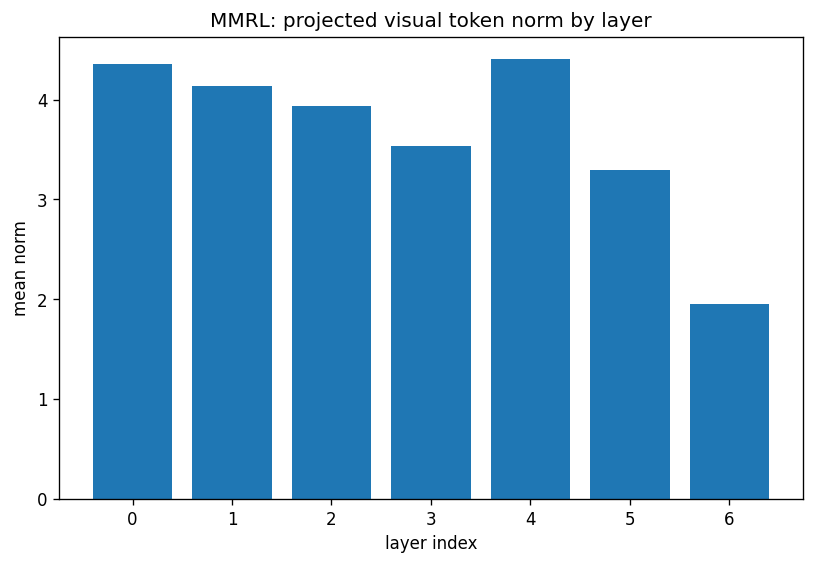

In [7]:
# ===== 4A. R 可视化：MMRL =====
show_bar(mmrl_R["R"]["token_norms"], "MMRL: token norms of R", "token index", "L2 norm")
show_heatmap(mmrl_R["R"]["pairwise_cosine"], "MMRL: pairwise cosine of R", "token", "token")
show_line(mmrl_R["R"]["svd"]["singular_values"], "MMRL: singular values of R", "index", "singular value")

mmrl_text_proj_norm = mmrl_R["projected_text"].norm(dim=2).mean(dim=1)
mmrl_visual_proj_norm = mmrl_R["projected_visual"].norm(dim=2).mean(dim=1)
show_bar(mmrl_text_proj_norm, "MMRL: projected text token norm by layer", "layer index", "mean norm")
show_bar(mmrl_visual_proj_norm, "MMRL: projected visual token norm by layer", "layer index", "mean norm")

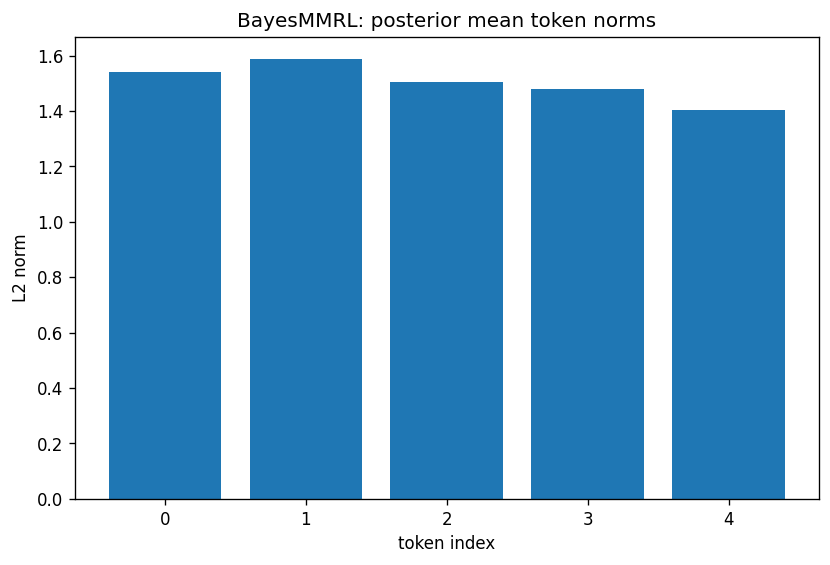

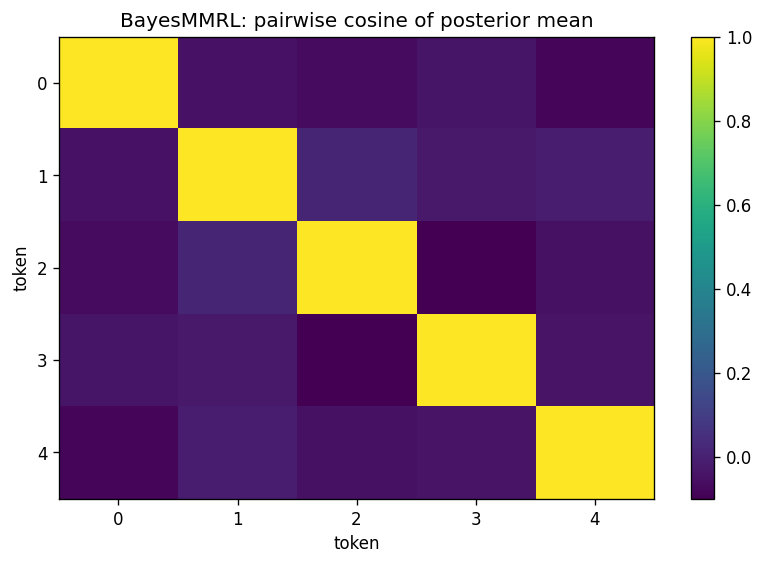

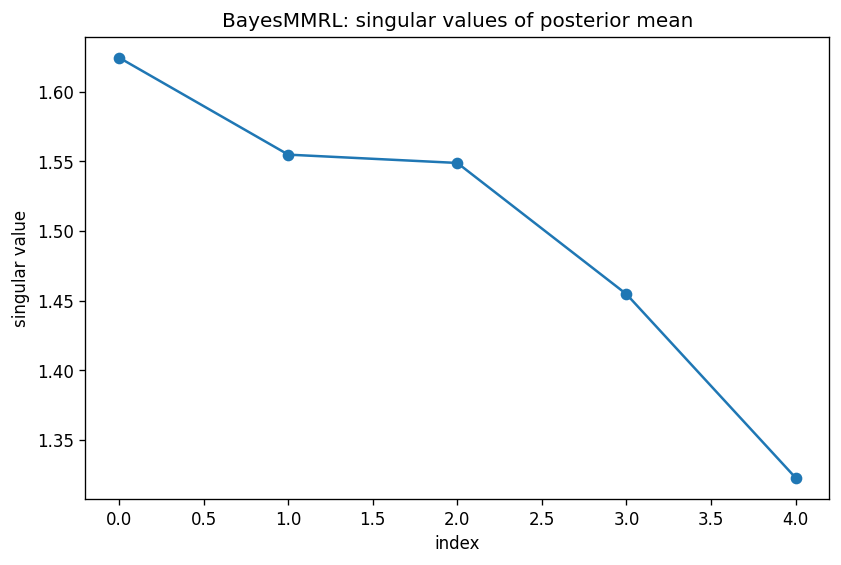

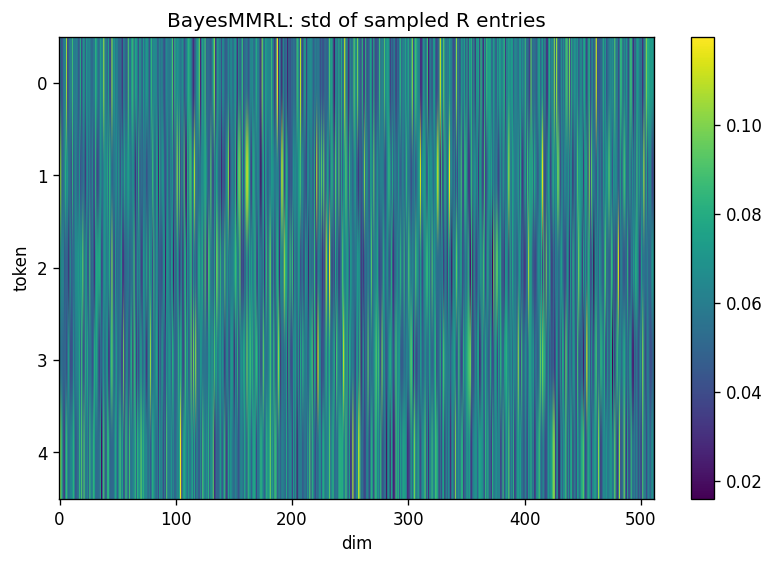

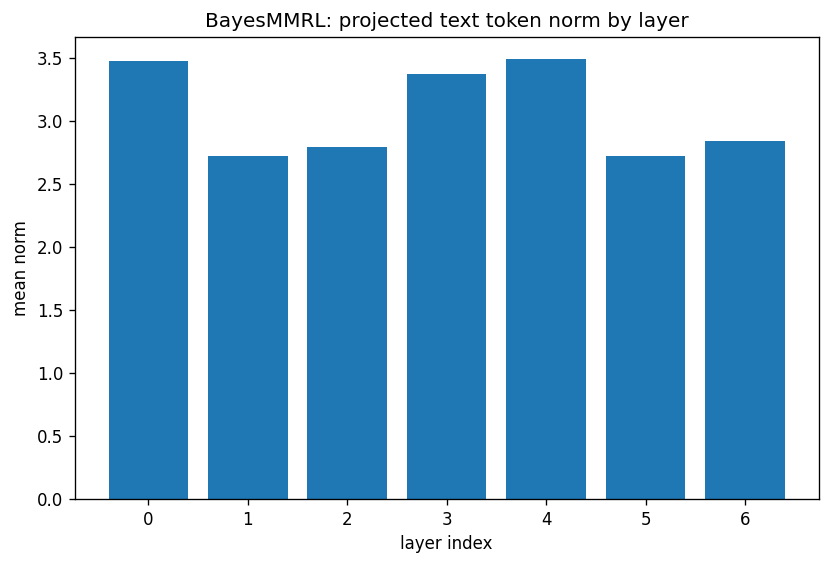

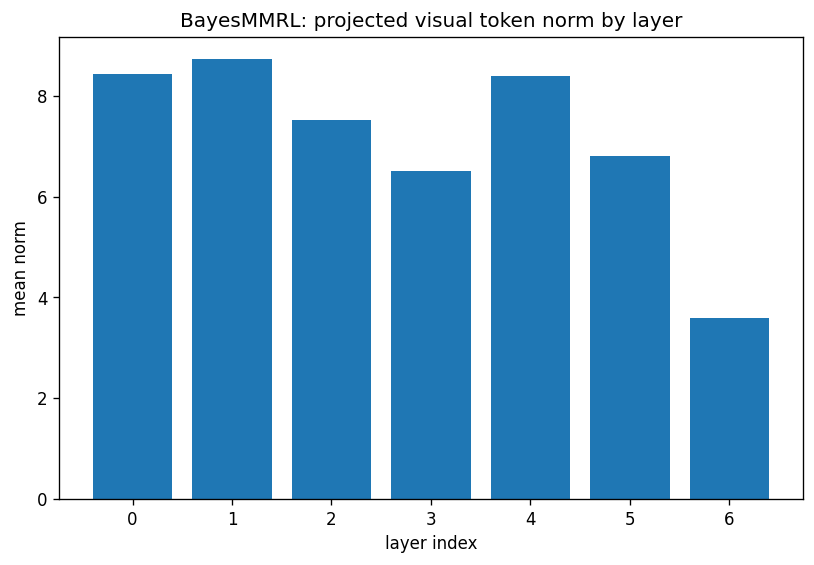

In [8]:
# ===== 4B. R 可视化：BayesMMRL =====
show_bar(bayes_R["R_mean"]["token_norms"], "BayesMMRL: posterior mean token norms", "token index", "L2 norm")
show_heatmap(bayes_R["R_mean"]["pairwise_cosine"], "BayesMMRL: pairwise cosine of posterior mean", "token", "token")
show_line(bayes_R["R_mean"]["svd"]["singular_values"], "BayesMMRL: singular values of posterior mean", "index", "singular value")
show_heatmap(bayes_R["posterior"]["sample_R_std_per_entry"], "BayesMMRL: std of sampled R entries", "dim", "token")

bayes_text_proj_norm = bayes_R["projected_text_mean"].norm(dim=2).mean(dim=1)
bayes_visual_proj_norm = bayes_R["projected_visual_mean"].norm(dim=2).mean(dim=1)
show_bar(bayes_text_proj_norm, "BayesMMRL: projected text token norm by layer", "layer index", "mean norm")
show_bar(bayes_visual_proj_norm, "BayesMMRL: projected visual token norm by layer", "layer index", "mean norm")

## 5. 分析特征与 logits

In [9]:
# ===== 5. 收集特征统计 =====

def collect_feature_bundle(trainer, split="test", max_batches=-1, mc_samples=8):
    method = trainer.method
    device = trainer.device

    if split == "val" and trainer.val_loader is not None:
        loader = trainer.val_loader
    else:
        split = "test"
        loader = trainer.test_loader

    eval_ctx = trainer.executor.build_eval_context(trainer, split)

    bucket = {
        "labels": [],
        "logits": [],
        "logits_rep": [],
        "logits_fusion": [],
        "img": [],
        "text_y": [],
        "img_ref": [],
        "text_ref_y": [],
        "correct_base": [],
        "correct_rep": [],
        "correct_fusion": [],
        "margin_base": [],
        "margin_rep": [],
        "margin_fusion": [],
        "conf_fusion": [],
    }

    if method.method_name == "BayesMMRL":
        bucket["mc_logit_std"] = []
        bucket["mc_img_std"] = []
        bucket["mc_text_std"] = []

    for bi, batch in enumerate(loader):
        if max_batches > 0 and bi >= max_batches:
            break

        image = batch["img"].to(device)
        label = batch["label"].to(device)

        outputs = method.forward_eval({"img": image, "label": label}, eval_ctx)
        routed = select_eval_logits(method.method_name, outputs, eval_ctx)

        logits = outputs.logits.detach()
        logits_rep = outputs.aux_logits["rep"].detach()
        logits_fusion = outputs.aux_logits.get("fusion", routed).detach()

        img = outputs.features["img"].detach()
        text = outputs.features["text"][: logits_fusion.shape[1]].detach()
        text_y = text[label]

        img_ref = method.image_encoder_clip(image.type(method.dtype))
        img_ref = img_ref / img_ref.norm(dim=-1, keepdim=True)
        img_ref = img_ref.detach()

        text_ref_y = method.text_features_clip[label].detach()

        pred_base = logits.argmax(dim=1)
        pred_rep = logits_rep.argmax(dim=1)
        pred_fusion = logits_fusion.argmax(dim=1)

        bucket["labels"].append(label.cpu())
        bucket["logits"].append(logits.cpu())
        bucket["logits_rep"].append(logits_rep.cpu())
        bucket["logits_fusion"].append(logits_fusion.cpu())
        bucket["img"].append(img.cpu())
        bucket["text_y"].append(text_y.cpu())
        bucket["img_ref"].append(img_ref.cpu())
        bucket["text_ref_y"].append(text_ref_y.cpu())

        bucket["correct_base"].append((pred_base == label).float().cpu())
        bucket["correct_rep"].append((pred_rep == label).float().cpu())
        bucket["correct_fusion"].append((pred_fusion == label).float().cpu())

        bucket["margin_base"].append(top2_margin(logits).cpu())
        bucket["margin_rep"].append(top2_margin(logits_rep).cpu())
        bucket["margin_fusion"].append(top2_margin(logits_fusion).cpu())
        bucket["conf_fusion"].append(F.softmax(logits_fusion, dim=1).max(dim=1).values.cpu())

        if method.method_name == "BayesMMRL":
            sample_outputs = method.model.forward_train_samples(image, mc_samples)
            fused = []
            imgs = []
            texts = []
            for lg, lg_rep, lg_f, imf, txtf in sample_outputs:
                fused.append(lg_f.detach().cpu())
                imgs.append(imf.detach().cpu())
                texts.append(txtf[: lg_f.shape[1]][label].detach().cpu())
            fused = torch.stack(fused, dim=0)
            imgs = torch.stack(imgs, dim=0)
            texts = torch.stack(texts, dim=0)

            bucket["mc_logit_std"].append(fused.std(dim=0).mean(dim=1))
            bucket["mc_img_std"].append(imgs.std(dim=0).mean(dim=1))
            bucket["mc_text_std"].append(texts.std(dim=0).mean(dim=1))

    for k, v in bucket.items():
        bucket[k] = torch.cat(v, dim=0)

    bundle = {
        "split": split,
        "num_samples": int(bucket["labels"].numel()),
        "accuracy_base": accuracy_from_logits(bucket["logits"], bucket["labels"]),
        "accuracy_rep": accuracy_from_logits(bucket["logits_rep"], bucket["labels"]),
        "accuracy_fusion": accuracy_from_logits(bucket["logits_fusion"], bucket["labels"]),
        "img_vs_img_ref_cos": F.cosine_similarity(bucket["img"], bucket["img_ref"], dim=1),
        "text_y_vs_text_ref_y_cos": F.cosine_similarity(bucket["text_y"], bucket["text_ref_y"], dim=1),
        "margin_base": bucket["margin_base"],
        "margin_rep": bucket["margin_rep"],
        "margin_fusion": bucket["margin_fusion"],
        "conf_fusion": bucket["conf_fusion"],
        "correct_base": bucket["correct_base"],
        "correct_rep": bucket["correct_rep"],
        "correct_fusion": bucket["correct_fusion"],
    }

    if trainer.method.method_name == "BayesMMRL":
        bundle["mc_logit_std"] = bucket["mc_logit_std"]
        bundle["mc_img_std"] = bucket["mc_img_std"]
        bundle["mc_text_std"] = bucket["mc_text_std"]

    return bundle

In [10]:
# 运行特征分析
mmrl_feat = collect_feature_bundle(mmrl_trainer, split="test", max_batches=MAX_BATCHES, mc_samples=MC_SAMPLES)
bayes_feat = collect_feature_bundle(bayes_trainer, split="test", max_batches=MAX_BATCHES, mc_samples=MC_SAMPLES)

print("MMRL accuracies:", mmrl_feat["accuracy_base"], mmrl_feat["accuracy_rep"], mmrl_feat["accuracy_fusion"])
print("Bayes accuracies:", bayes_feat["accuracy_base"], bayes_feat["accuracy_rep"], bayes_feat["accuracy_fusion"])

MMRL accuracies: 96.59228920936584 95.86206674575806 96.71399593353271
Bayes accuracies: 96.59228920936584 95.90263962745667 96.55172228813171


[MMRL] img vs img_ref cosine: mean=0.9853, std=0.0082
[MMRL] text_y vs text_ref_y cosine: mean=0.9867, std=0.0096
[BayesMMRL] img vs img_ref cosine: mean=0.9852, std=0.0081
[BayesMMRL] text_y vs text_ref_y cosine: mean=0.9878, std=0.0100


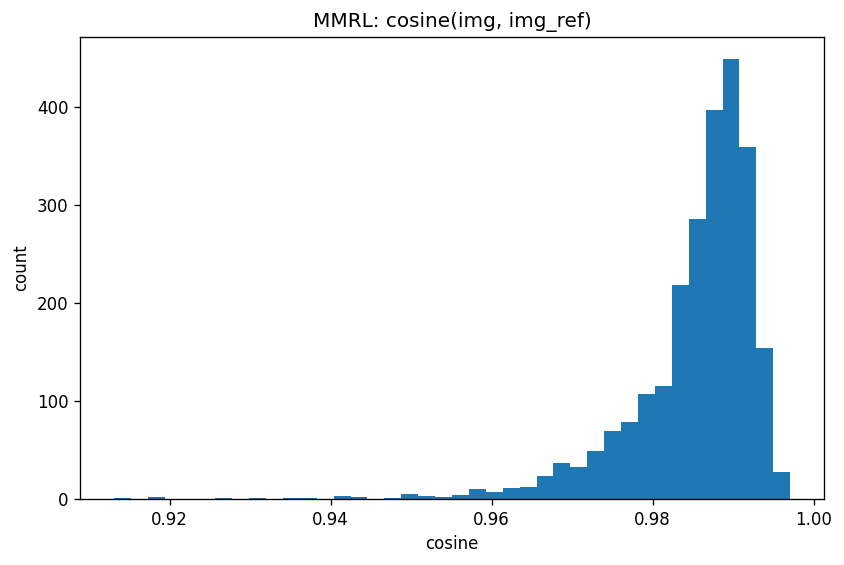

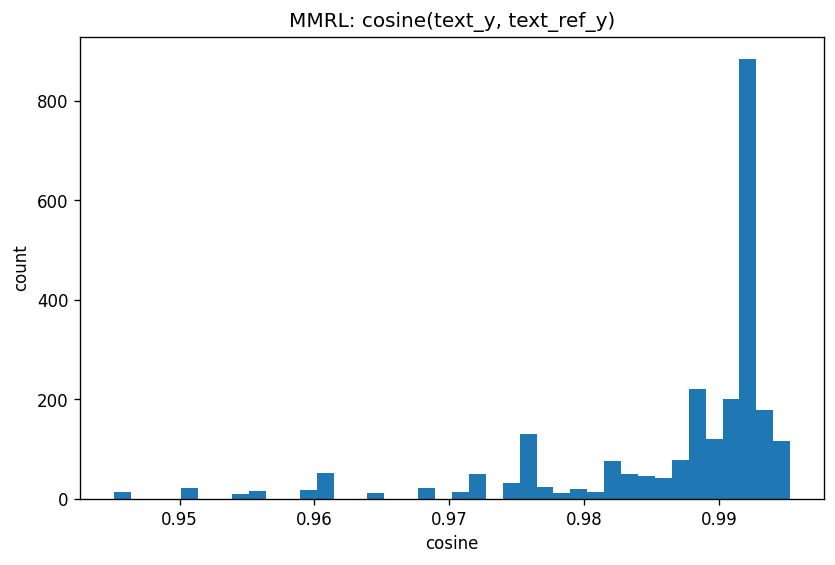

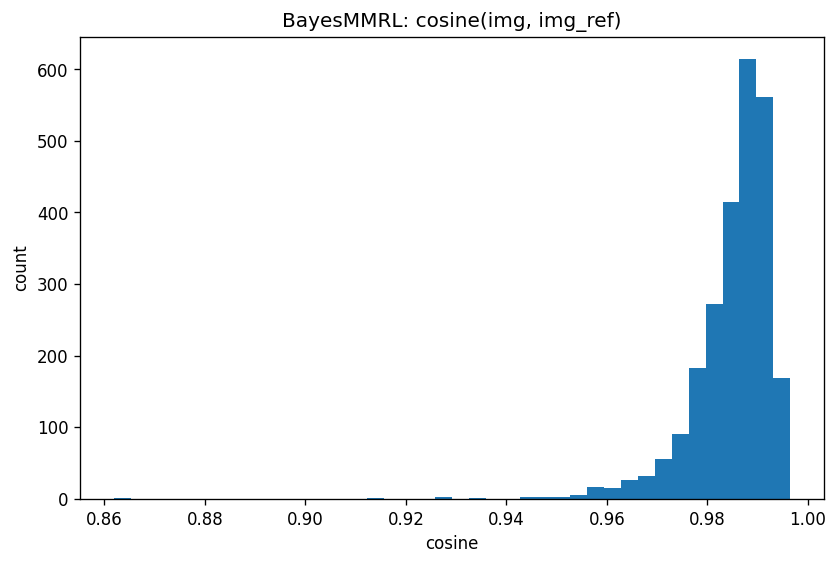

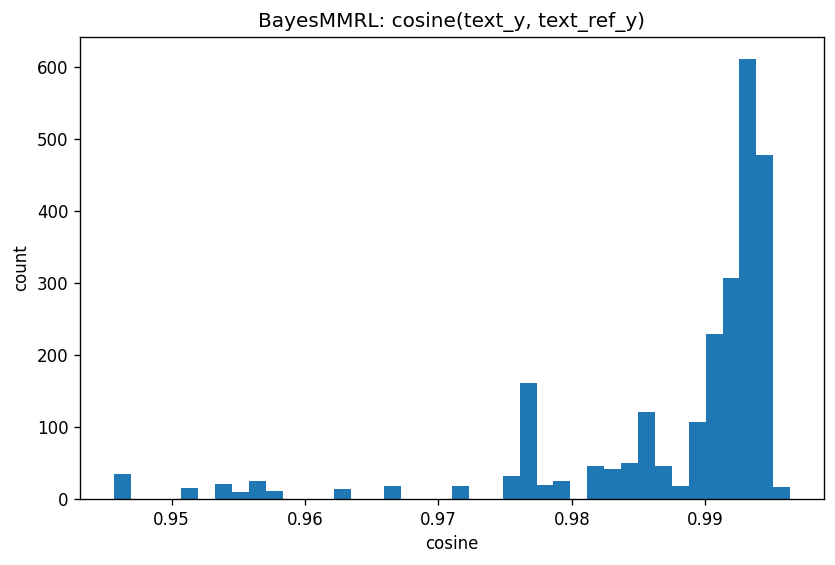

In [11]:
# ===== 5A. 对齐分析 =====
def summarize_alignment(bundle, name):
    img_mean, img_std = mean_std(bundle["img_vs_img_ref_cos"])
    txt_mean, txt_std = mean_std(bundle["text_y_vs_text_ref_y_cos"])
    print(f"[{name}] img vs img_ref cosine: mean={img_mean:.4f}, std={img_std:.4f}")
    print(f"[{name}] text_y vs text_ref_y cosine: mean={txt_mean:.4f}, std={txt_std:.4f}")

summarize_alignment(mmrl_feat, "MMRL")
summarize_alignment(bayes_feat, "BayesMMRL")

show_hist(mmrl_feat["img_vs_img_ref_cos"], "MMRL: cosine(img, img_ref)", "cosine")
show_hist(mmrl_feat["text_y_vs_text_ref_y_cos"], "MMRL: cosine(text_y, text_ref_y)", "cosine")

show_hist(bayes_feat["img_vs_img_ref_cos"], "BayesMMRL: cosine(img, img_ref)", "cosine")
show_hist(bayes_feat["text_y_vs_text_ref_y_cos"], "BayesMMRL: cosine(text_y, text_ref_y)", "cosine")

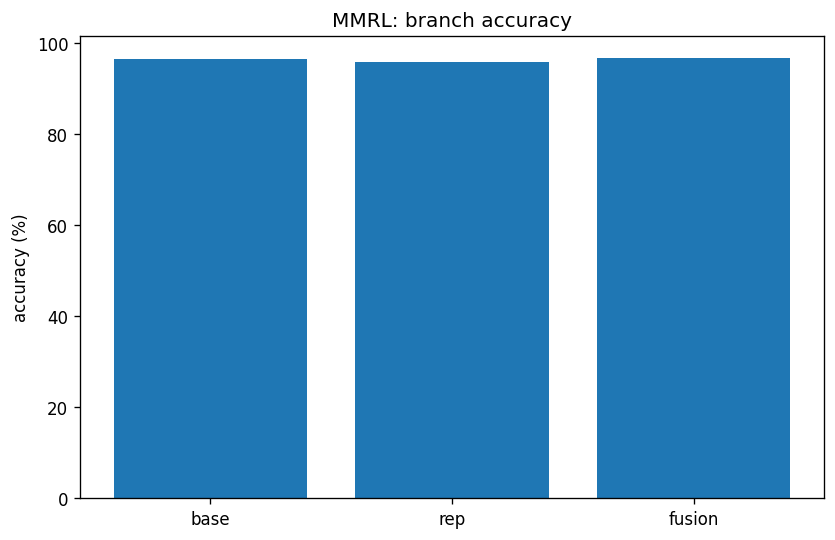

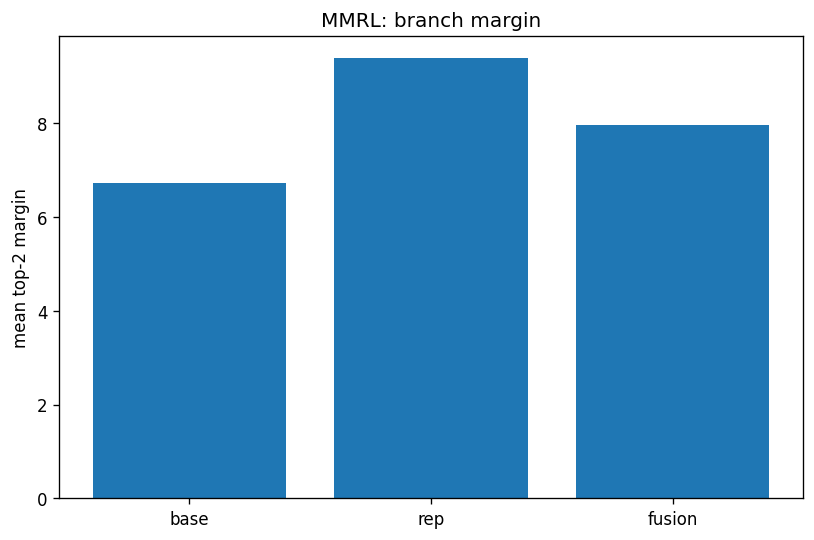

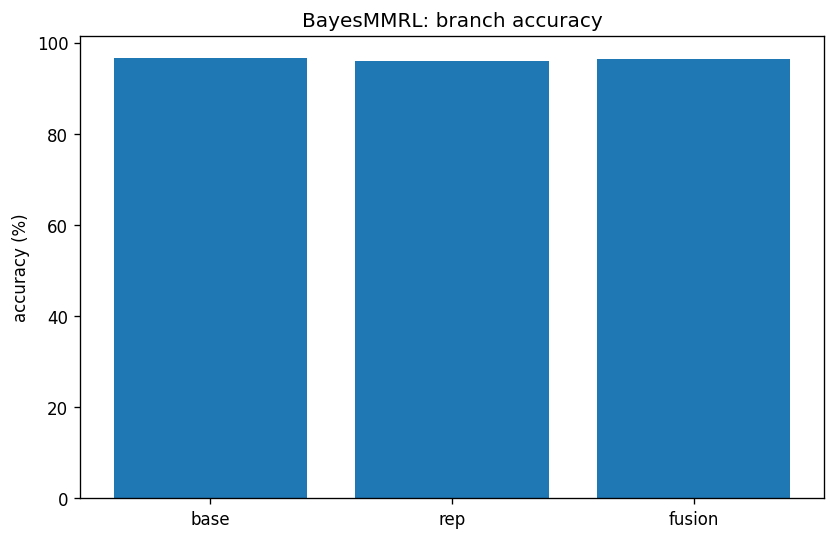

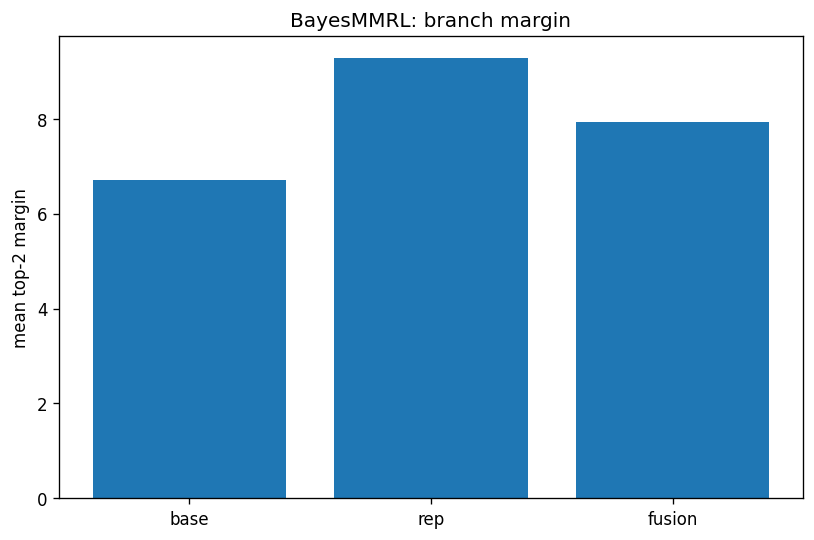

In [17]:
# ===== 5B. 三条分支：accuracy 与 margin =====
def plot_branch_summary(bundle, title_prefix):
    accs = np.array([
        bundle["accuracy_base"],
        bundle["accuracy_rep"],
        bundle["accuracy_fusion"],
    ])
    margins = np.array([
        float(bundle["margin_base"].mean().item()),
        float(bundle["margin_rep"].mean().item()),
        float(bundle["margin_fusion"].mean().item()),
    ])

    plt.figure()
    plt.bar(["base", "rep", "fusion"], accs)
    plt.title(f"{title_prefix}: branch accuracy")
    plt.ylabel("accuracy (%)")
    plt.show()

    plt.figure()
    plt.bar(["base", "rep", "fusion"], margins)
    plt.title(f"{title_prefix}: branch margin")
    plt.ylabel("mean top-2 margin")
    plt.show()

plot_branch_summary(mmrl_feat, "MMRL")
plot_branch_summary(bayes_feat, "BayesMMRL")

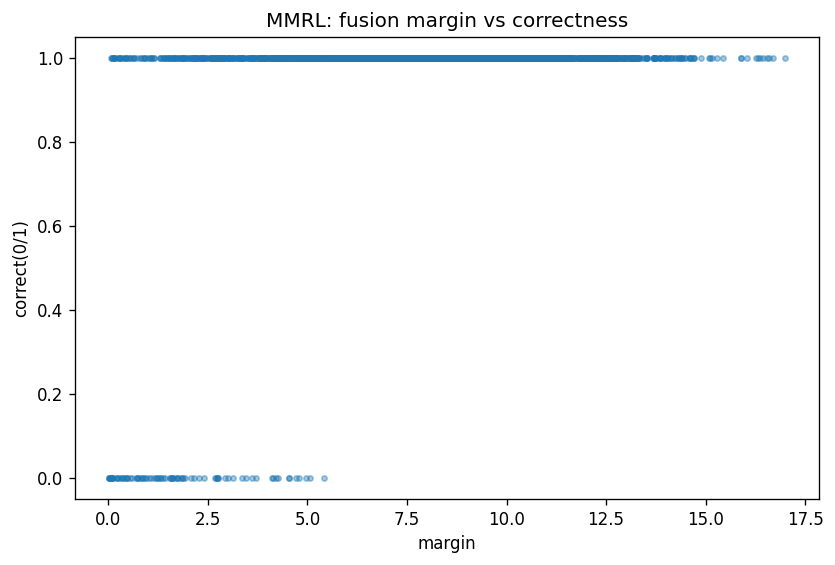

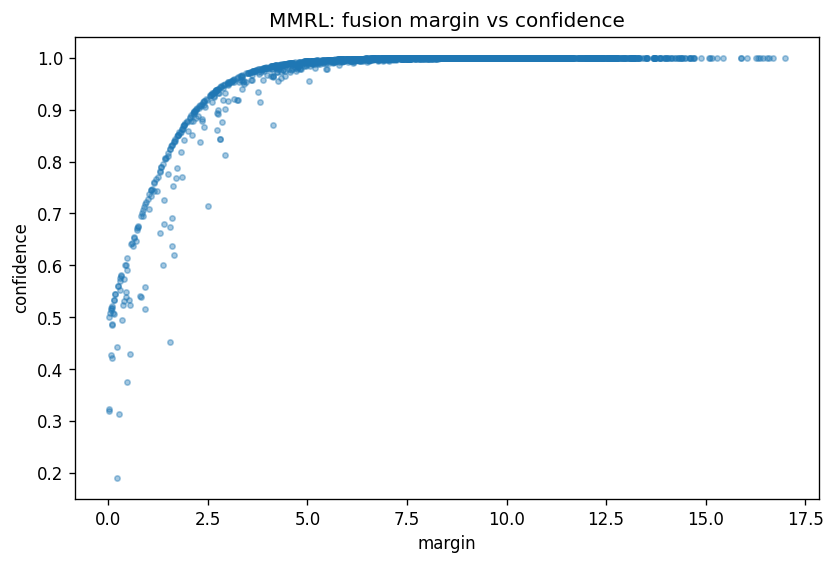

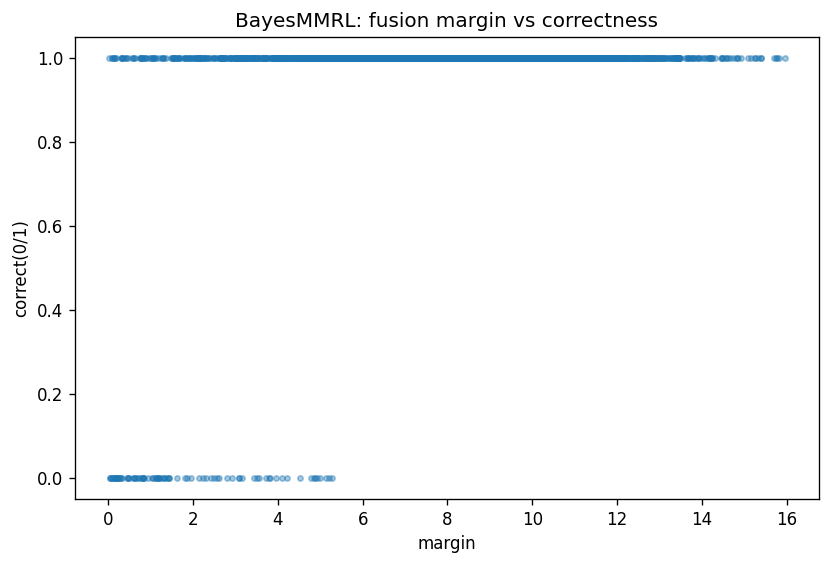

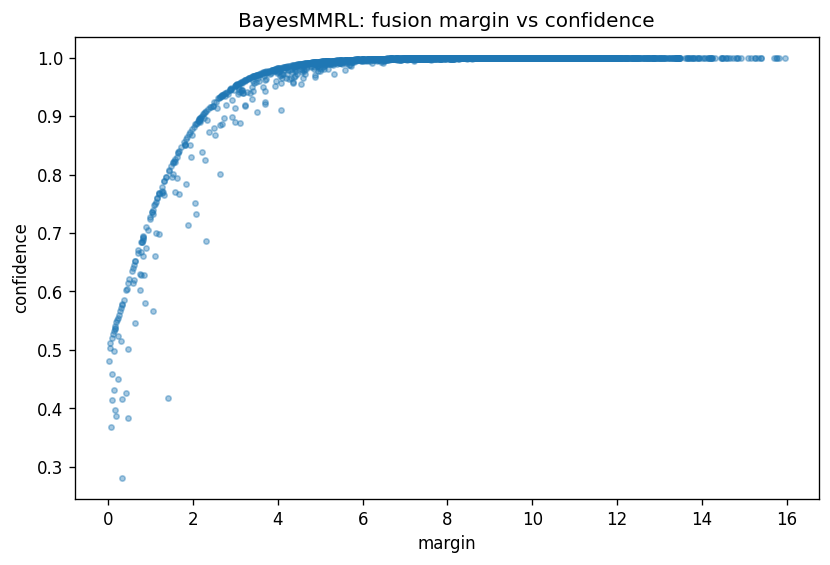

In [13]:
# ===== 5C. margin 与正确性 / confidence 的关系 =====
show_scatter(mmrl_feat["margin_fusion"], mmrl_feat["correct_fusion"], "MMRL: fusion margin vs correctness", "margin", "correct(0/1)")
show_scatter(mmrl_feat["margin_fusion"], mmrl_feat["conf_fusion"], "MMRL: fusion margin vs confidence", "margin", "confidence")

show_scatter(bayes_feat["margin_fusion"], bayes_feat["correct_fusion"], "BayesMMRL: fusion margin vs correctness", "margin", "correct(0/1)")
show_scatter(bayes_feat["margin_fusion"], bayes_feat["conf_fusion"], "BayesMMRL: fusion margin vs confidence", "margin", "confidence")

## 6. BayesMMRL 的额外分析：MC 不确定性

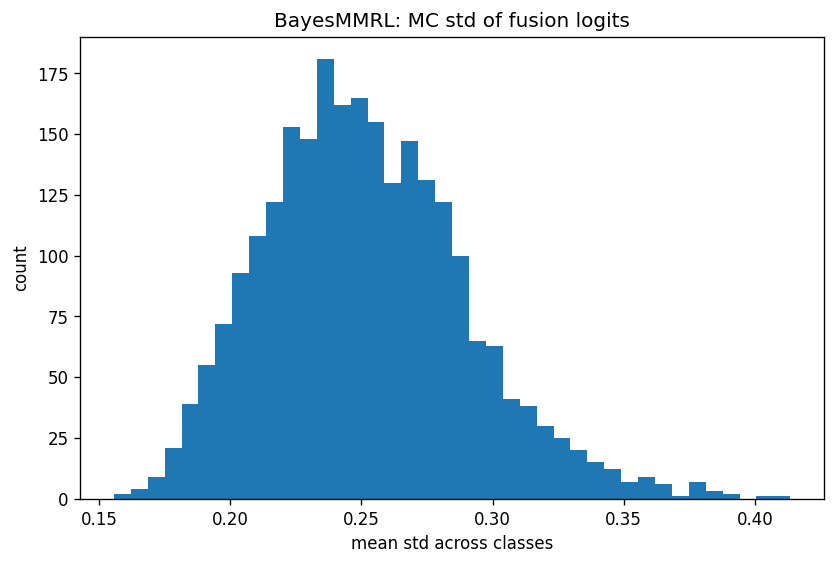

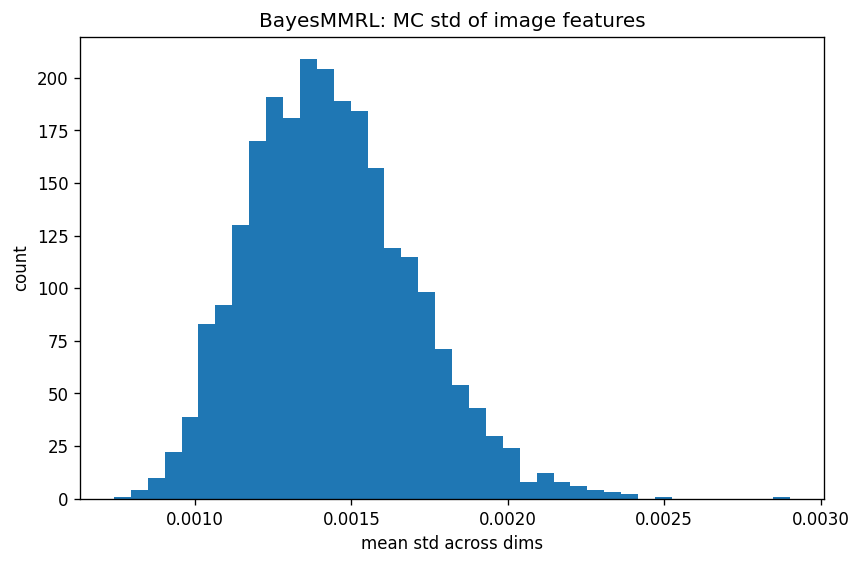

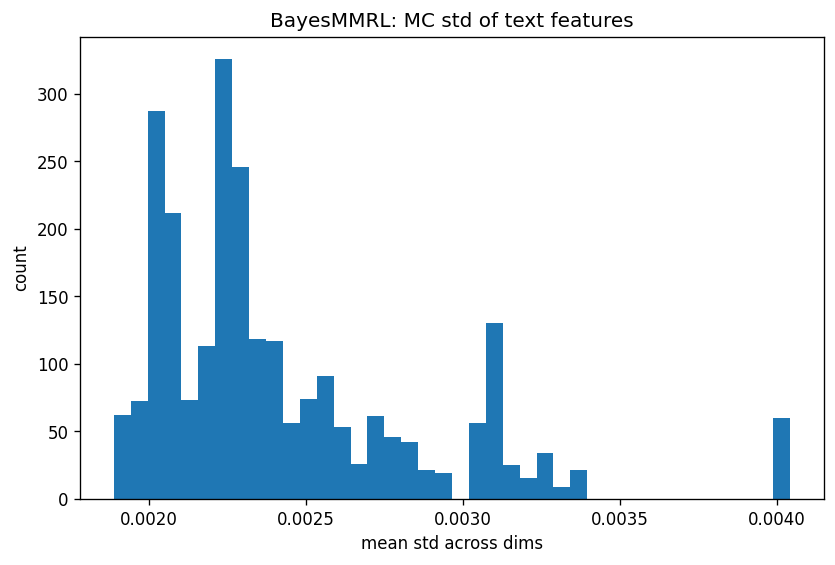

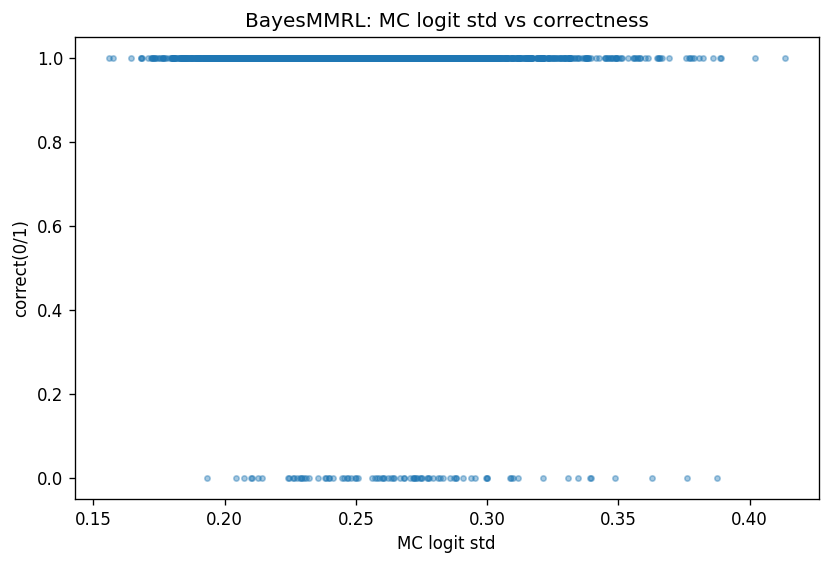

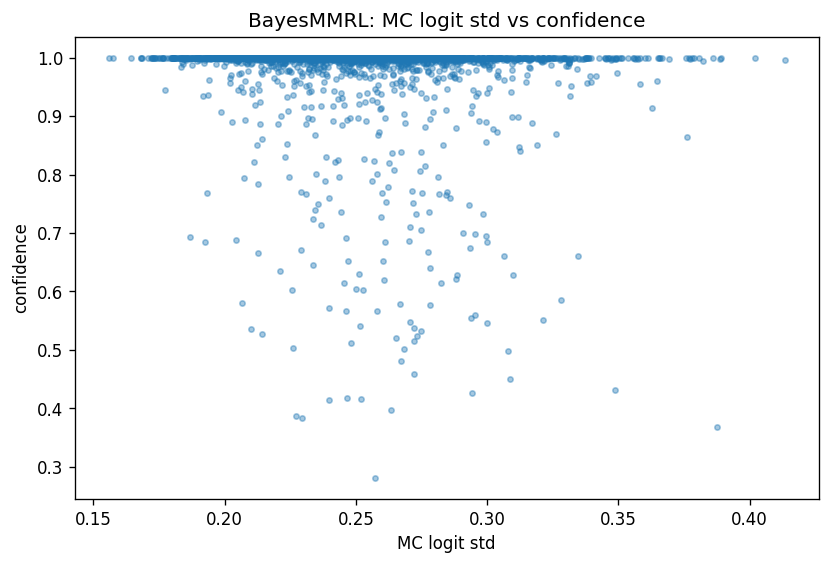

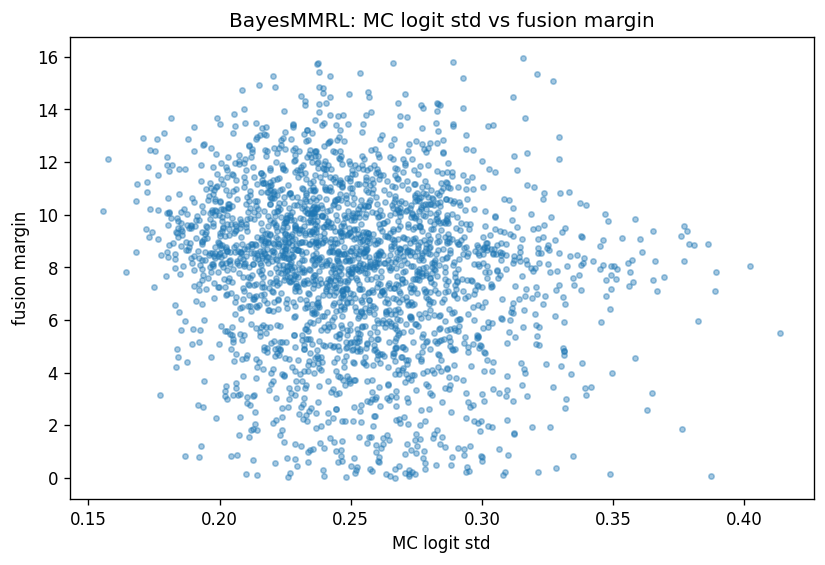

Bayes mean MC logit std = 0.25146257877349854
Bayes mean MC img std   = 0.0014371597208082676
Bayes mean MC text std  = 0.0024255395401269197


In [14]:
# ===== 6. Bayes uncertainty analysis =====
show_hist(bayes_feat["mc_logit_std"], "BayesMMRL: MC std of fusion logits", "mean std across classes")
show_hist(bayes_feat["mc_img_std"], "BayesMMRL: MC std of image features", "mean std across dims")
show_hist(bayes_feat["mc_text_std"], "BayesMMRL: MC std of text features", "mean std across dims")

show_scatter(bayes_feat["mc_logit_std"], bayes_feat["correct_fusion"], "BayesMMRL: MC logit std vs correctness", "MC logit std", "correct(0/1)")
show_scatter(bayes_feat["mc_logit_std"], bayes_feat["conf_fusion"], "BayesMMRL: MC logit std vs confidence", "MC logit std", "confidence")
show_scatter(bayes_feat["mc_logit_std"], bayes_feat["margin_fusion"], "BayesMMRL: MC logit std vs fusion margin", "MC logit std", "fusion margin")

print("Bayes mean MC logit std =", float(bayes_feat["mc_logit_std"].mean().item()))
print("Bayes mean MC img std   =", float(bayes_feat["mc_img_std"].mean().item()))
print("Bayes mean MC text std  =", float(bayes_feat["mc_text_std"].mean().item()))

In [18]:
# ===== 6A. 不确定性验证 helper =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def pearson_corr(x, y):
    x = to_numpy(x).reshape(-1)
    y = to_numpy(y).reshape(-1)
    if x.std() < 1e-12 or y.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def spearman_corr(x, y):
    x = pd.Series(to_numpy(x).reshape(-1)).rank(method="average").to_numpy()
    y = pd.Series(to_numpy(y).reshape(-1)).rank(method="average").to_numpy()
    if x.std() < 1e-12 or y.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])

def binary_auc(scores, positive_labels):
    """
    用 uncertainty 作为 score，positive_labels=1 表示“错误样本”。
    这里计算的是：uncertainty 作为 error detector 的 AUROC。
    """
    scores = to_numpy(scores).reshape(-1)
    y = to_numpy(positive_labels).reshape(-1).astype(int)

    n_pos = int(y.sum())
    n_neg = int((1 - y).sum())
    if n_pos == 0 or n_neg == 0:
        return np.nan

    ranks = pd.Series(scores).rank(method="average").to_numpy()
    pos_rank_sum = ranks[y == 1].sum()
    auc = (pos_rank_sum - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)

def build_uncertainty_df(bayes_feat):
    df = pd.DataFrame({
        "uncertainty": to_numpy(bayes_feat["mc_logit_std"]).reshape(-1),
        "margin": to_numpy(bayes_feat["margin_fusion"]).reshape(-1),
        "confidence": to_numpy(bayes_feat["conf_fusion"]).reshape(-1),
        "correct": to_numpy(bayes_feat["correct_fusion"]).reshape(-1),
    })
    df["error"] = 1.0 - df["correct"]
    return df

In [19]:
# ===== 6B. 核心统计验证 =====
unc_df = build_uncertainty_df(bayes_feat)

correct_df = unc_df[unc_df["correct"] == 1.0]
wrong_df = unc_df[unc_df["correct"] == 0.0]

print("num samples =", len(unc_df))
print("num correct =", len(correct_df))
print("num wrong   =", len(wrong_df))
print()

print("mean uncertainty | correct =", correct_df["uncertainty"].mean())
print("mean uncertainty | wrong   =", wrong_df["uncertainty"].mean())
print()

print("pearson(uncertainty, margin)     =", pearson_corr(unc_df["uncertainty"], unc_df["margin"]))
print("spearman(uncertainty, margin)    =", spearman_corr(unc_df["uncertainty"], unc_df["margin"]))
print()

print("pearson(uncertainty, confidence) =", pearson_corr(unc_df["uncertainty"], unc_df["confidence"]))
print("spearman(uncertainty, confidence)=", spearman_corr(unc_df["uncertainty"], unc_df["confidence"]))
print()

print("pearson(uncertainty, correct)    =", pearson_corr(unc_df["uncertainty"], unc_df["correct"]))
print("spearman(uncertainty, correct)   =", spearman_corr(unc_df["uncertainty"], unc_df["correct"]))
print()

print("AUROC of uncertainty for detecting errors =", binary_auc(unc_df["uncertainty"], unc_df["error"]))

num samples = 2465
num correct = 2380
num wrong   = 85

mean uncertainty | correct = 0.2508762
mean uncertainty | wrong   = 0.26788068

pearson(uncertainty, margin)     = -0.14656967611202013
spearman(uncertainty, margin)    = -0.1587224168181063

pearson(uncertainty, confidence) = -0.08426435078866852
spearman(uncertainty, confidence)= -0.15492095989537583

pearson(uncertainty, correct)    = -0.08075816577653275
spearman(uncertainty, correct)   = -0.07662752701822344

AUROC of uncertainty for detecting errors = 0.6212308452792882


In [20]:
# ===== 6C. uncertainty 分桶分析 =====
n_bins = 10

unc_df["unc_bin"] = pd.qcut(
    unc_df["uncertainty"],
    q=n_bins,
    labels=False,
    duplicates="drop"
)

unc_bin_table = (
    unc_df.groupby("unc_bin")
    .agg(
        count=("uncertainty", "size"),
        uncertainty_mean=("uncertainty", "mean"),
        uncertainty_min=("uncertainty", "min"),
        uncertainty_max=("uncertainty", "max"),
        error_rate=("error", "mean"),
        correct_rate=("correct", "mean"),
        margin_mean=("margin", "mean"),
        confidence_mean=("confidence", "mean"),
    )
    .reset_index()
)

unc_bin_table

,unc_bin,count,uncertainty_mean,uncertainty_min,uncertainty_max,error_rate,correct_rate,margin_mean,confidence_mean
0,0,247,0.191967,0.155734,0.203750,0.004049,0.995951,8.959363,0.993550
1,1,246,0.211546,0.203761,0.218386,0.024390,0.975610,8.200039,0.983049
2,2,247,0.223985,0.218430,0.228995,0.028340,0.971660,8.258872,0.983235
3,3,246,0.234203,0.229049,0.238462,0.024390,0.975610,8.291470,0.982502
4,4,247,0.243566,0.238501,0.248280,0.036437,0.963563,8.089832,0.974869
5,5,247,0.253242,0.248282,0.258284,0.024291,0.975708,7.808251,0.977315
6,6,245,0.264144,0.258291,0.269910,0.044898,0.955102,7.348983,0.971084
7,7,247,0.275838,0.269920,0.282113,0.056680,0.943320,7.546175,0.965592
8,8,246,0.290194,0.282124,0.300656,0.048780,0.951219,7.530572,0.968321
9,9,247,0.325969,0.300692,0.413438,0.052632,0.947368,7.332705,0.972973


In [25]:
# ===== 6F. hardest vs easiest samples =====
low_q = unc_df["uncertainty"].quantile(0.2)
high_q = unc_df["uncertainty"].quantile(0.8)

easy_like = unc_df[unc_df["uncertainty"] <= low_q]
hard_like = unc_df[unc_df["uncertainty"] >= high_q]

summary_df = pd.DataFrame([
    {
        "group": "low_uncertainty_20%",
        "count": len(easy_like),
        "error_rate": easy_like["error"].mean(),
        "margin_mean": easy_like["margin"].mean(),
        "confidence_mean": easy_like["confidence"].mean(),
        "uncertainty_mean": easy_like["uncertainty"].mean(),
    },
    {
        "group": "high_uncertainty_20%",
        "count": len(hard_like),
        "error_rate": hard_like["error"].mean(),
        "margin_mean": hard_like["margin"].mean(),
        "confidence_mean": hard_like["confidence"].mean(),
        "uncertainty_mean": hard_like["uncertainty"].mean(),
    },
])

summary_df

,group,count,error_rate,margin_mean,confidence_mean,uncertainty_mean
0,low_uncertainty_20%,493,0.014199,8.580470,0.988311,0.201737
1,high_uncertainty_20%,493,0.050710,7.431438,0.970652,0.308117


/tmp/ipykernel_6165/3997458063.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


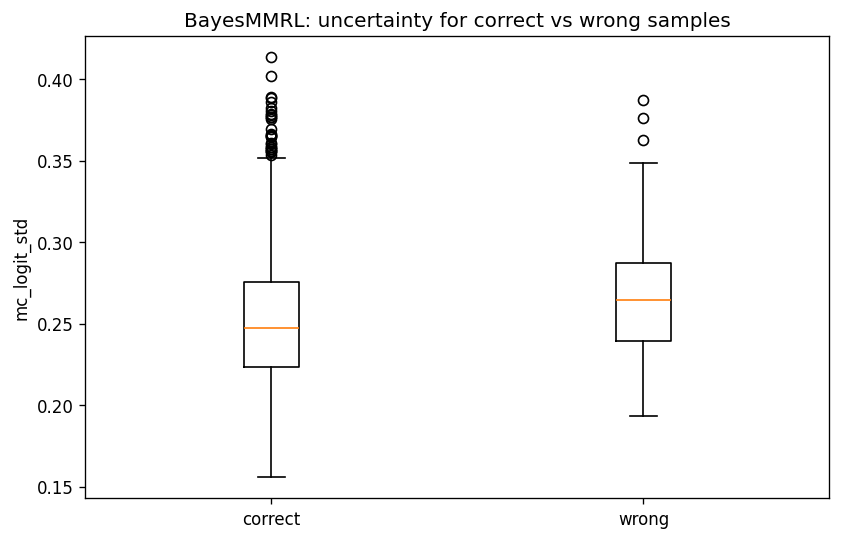

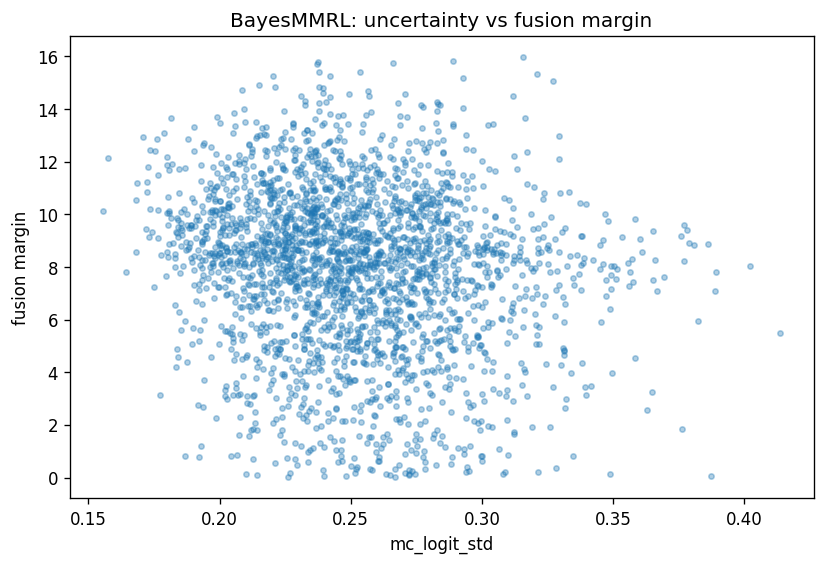

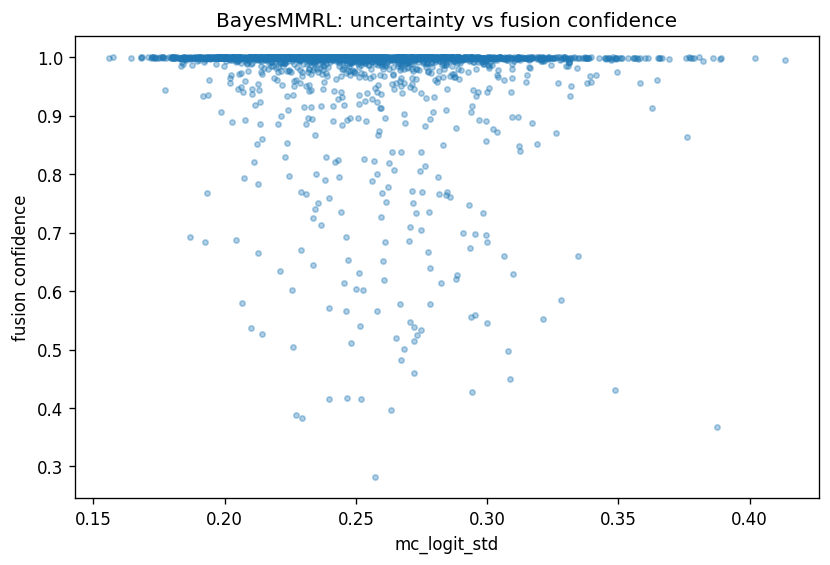

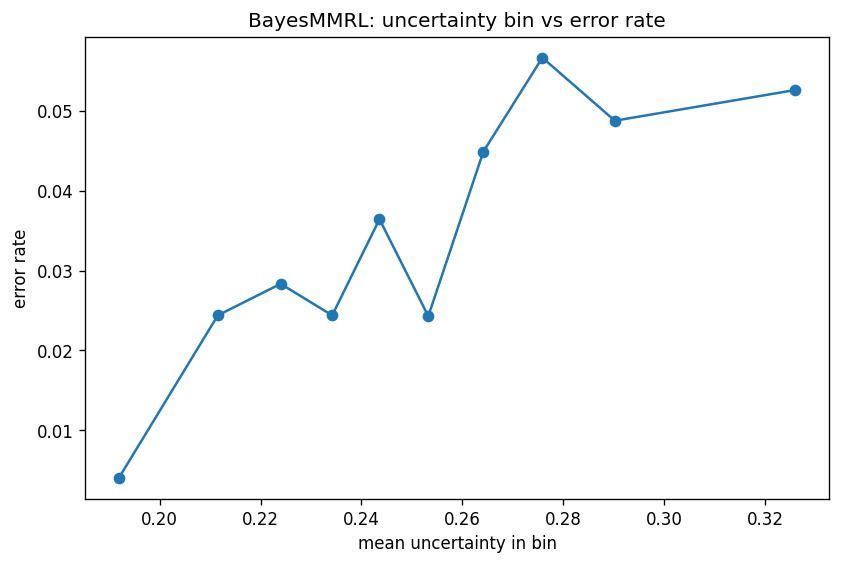

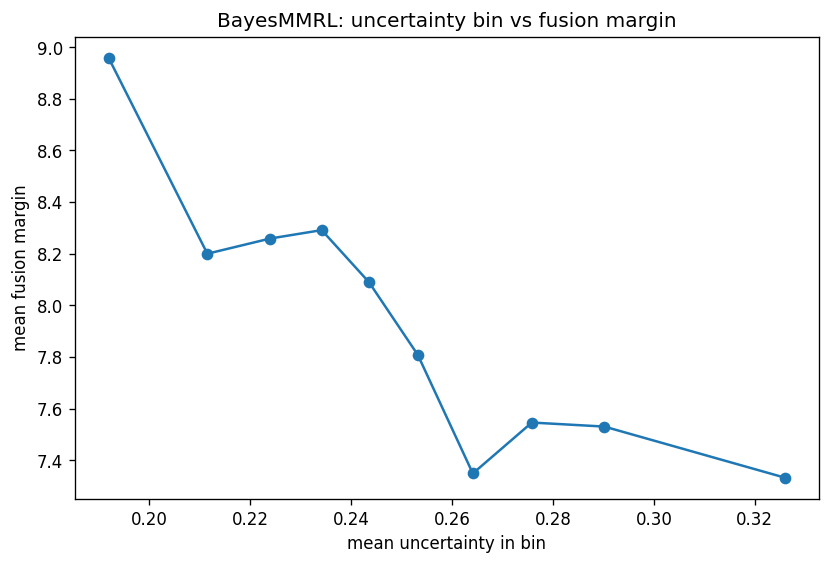

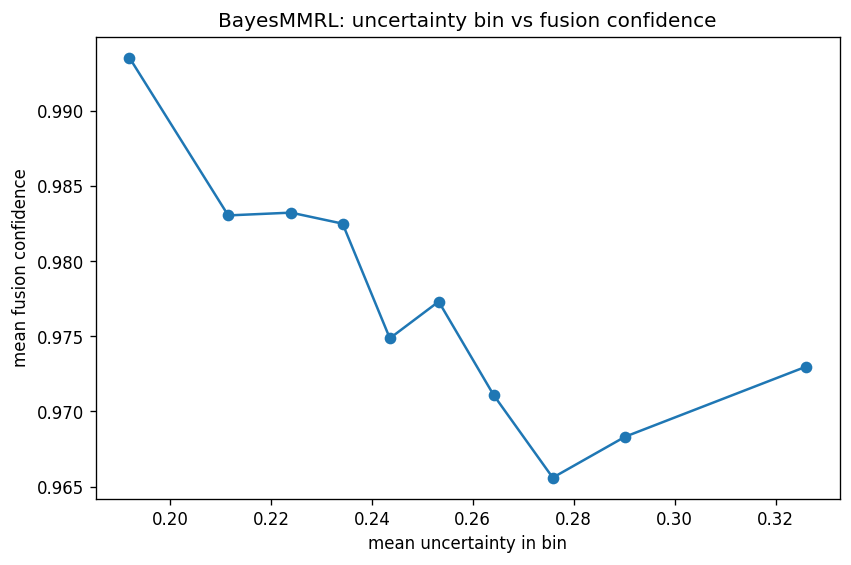

In [21]:
# ===== 6D. 可视化：错误样本 / 难样本敏感性 =====

# 1) uncertainty 在 correct / wrong 上的箱线图
plt.figure()
plt.boxplot(
    [
        correct_df["uncertainty"].to_numpy(),
        wrong_df["uncertainty"].to_numpy(),
    ],
    labels=["correct", "wrong"]
)
plt.title("BayesMMRL: uncertainty for correct vs wrong samples")
plt.ylabel("mc_logit_std")
plt.show()

# 2) uncertainty vs margin
plt.figure()
plt.scatter(unc_df["uncertainty"], unc_df["margin"], alpha=0.35, s=10)
plt.title("BayesMMRL: uncertainty vs fusion margin")
plt.xlabel("mc_logit_std")
plt.ylabel("fusion margin")
plt.show()

# 3) uncertainty vs confidence
plt.figure()
plt.scatter(unc_df["uncertainty"], unc_df["confidence"], alpha=0.35, s=10)
plt.title("BayesMMRL: uncertainty vs fusion confidence")
plt.xlabel("mc_logit_std")
plt.ylabel("fusion confidence")
plt.show()

# 4) uncertainty bin vs error rate
plt.figure()
plt.plot(unc_bin_table["uncertainty_mean"], unc_bin_table["error_rate"], marker="o")
plt.title("BayesMMRL: uncertainty bin vs error rate")
plt.xlabel("mean uncertainty in bin")
plt.ylabel("error rate")
plt.show()

# 5) uncertainty bin vs margin
plt.figure()
plt.plot(unc_bin_table["uncertainty_mean"], unc_bin_table["margin_mean"], marker="o")
plt.title("BayesMMRL: uncertainty bin vs fusion margin")
plt.xlabel("mean uncertainty in bin")
plt.ylabel("mean fusion margin")
plt.show()

# 6) uncertainty bin vs confidence
plt.figure()
plt.plot(unc_bin_table["uncertainty_mean"], unc_bin_table["confidence_mean"], marker="o")
plt.title("BayesMMRL: uncertainty bin vs fusion confidence")
plt.xlabel("mean uncertainty in bin")
plt.ylabel("mean fusion confidence")
plt.show()

In [22]:
# ===== 6E. 自动判断 =====
mean_unc_correct = correct_df["uncertainty"].mean()
mean_unc_wrong = wrong_df["uncertainty"].mean()

corr_margin = spearman_corr(unc_df["uncertainty"], unc_df["margin"])
corr_conf = spearman_corr(unc_df["uncertainty"], unc_df["confidence"])
corr_correct = spearman_corr(unc_df["uncertainty"], unc_df["correct"])
error_auc = binary_auc(unc_df["uncertainty"], unc_df["error"])

print("=== Decision summary ===")
print(f"wrong > correct uncertainty ? {mean_unc_wrong > mean_unc_correct}")
print(f"spearman(uncertainty, margin)     = {corr_margin:.4f}")
print(f"spearman(uncertainty, confidence) = {corr_conf:.4f}")
print(f"spearman(uncertainty, correct)    = {corr_correct:.4f}")
print(f"error-detection AUROC             = {error_auc:.4f}")

if (
    (mean_unc_wrong > mean_unc_correct) and
    (corr_margin < 0) and
    (corr_conf < 0) and
    (corr_correct < 0)
):
    print("\\n结论：当前 Bayes 不确定性对难样本是敏感的。")
else:
    print("\\n结论：当前 Bayes 不确定性和难样本的对应关系还不够明显。")

=== Decision summary ===
wrong > correct uncertainty ? True
spearman(uncertainty, margin)     = -0.1587
spearman(uncertainty, confidence) = -0.1549
spearman(uncertainty, correct)    = -0.0766
error-detection AUROC             = 0.6212
\n结论：当前 Bayes 不确定性对难样本是敏感的。


## 7. 直接对比 MMRL vs BayesMMRL

In [23]:
# ===== 7. Compare summary table =====
compare_df = pd.DataFrame([
    {
        "method": "MMRL",
        "R_effective_rank": mmrl_R["R"]["svd"]["effective_rank"],
        "R_pairwise_cos_mean": mmrl_R["R"]["pairwise_cosine_summary"]["mean"],
        "acc_base": mmrl_feat["accuracy_base"],
        "acc_rep": mmrl_feat["accuracy_rep"],
        "acc_fusion": mmrl_feat["accuracy_fusion"],
        "img_ref_align": float(mmrl_feat["img_vs_img_ref_cos"].mean().item()),
        "text_ref_align": float(mmrl_feat["text_y_vs_text_ref_y_cos"].mean().item()),
        "margin_base": float(mmrl_feat["margin_base"].mean().item()),
        "margin_rep": float(mmrl_feat["margin_rep"].mean().item()),
        "margin_fusion": float(mmrl_feat["margin_fusion"].mean().item()),
    },
    {
        "method": "BayesMMRL",
        "R_effective_rank": bayes_R["R_mean"]["svd"]["effective_rank"],
        "R_pairwise_cos_mean": bayes_R["R_mean"]["pairwise_cosine_summary"]["mean"],
        "posterior_sigma": bayes_R["posterior"]["sigma_scalar"],
        "acc_base": bayes_feat["accuracy_base"],
        "acc_rep": bayes_feat["accuracy_rep"],
        "acc_fusion": bayes_feat["accuracy_fusion"],
        "img_ref_align": float(bayes_feat["img_vs_img_ref_cos"].mean().item()),
        "text_ref_align": float(bayes_feat["text_y_vs_text_ref_y_cos"].mean().item()),
        "margin_base": float(bayes_feat["margin_base"].mean().item()),
        "margin_rep": float(bayes_feat["margin_rep"].mean().item()),
        "margin_fusion": float(bayes_feat["margin_fusion"].mean().item()),
        "mc_logit_std": float(bayes_feat["mc_logit_std"].mean().item()),
        "mc_img_std": float(bayes_feat["mc_img_std"].mean().item()),
        "mc_text_std": float(bayes_feat["mc_text_std"].mean().item()),
    },
])

compare_df

,method,R_effective_rank,R_pairwise_cos_mean,acc_base,acc_rep,acc_fusion,img_ref_align,text_ref_align,margin_base,margin_rep,margin_fusion,posterior_sigma,mc_logit_std,mc_img_std,mc_text_std
0,MMRL,4.895913,-0.072391,96.592289,95.862067,96.713996,0.985285,0.986661,6.729884,9.390538,7.971018,NaN,NaN,NaN,NaN
1,BayesMMRL,4.953028,-0.044174,96.592289,95.902640,96.551722,0.985155,0.987788,6.719187,9.279259,7.937016,0.062627,0.251463,0.001437,0.002426


## 8. 结论模板

### A. `R` 的变化
- MMRL 的 `R` 是否呈现高相关、低秩、少数 token 主导？
- BayesMMRL 的 `posterior_mean` 是否更分散、更稳定？
- `sigma` 是否落在合理范围？

### B. 特征变化
- `img` / `text` 是否仍与 `img_ref` / `text_ref` 高对齐？
- 若对齐高且 `fusion` 更强，说明方法是在 CLIP 先验附近做判别增强。

### C. 有效性来源
- 若 `fusion > base` 且 `fusion > rep`，说明有效性来自互补融合。
- 若 Bayes 的 `MC logit std` 与错误样本、小 margin、低 confidence 强相关，
  说明 Bayes 的作用是给 `R` 提供稳健性和不确定性建模，而不是单纯加噪声。

In [24]:
# ===== 9. 可选：保存关键表格 =====
save_dir = REPO_ROOT / "analysis_outputs"
save_dir.mkdir(exist_ok=True)

compare_df.to_csv(save_dir / "mmrl_vs_bayes_summary.csv", index=False)

with open(save_dir / "mmrl_R_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "pairwise_cosine_summary": mmrl_R["R"]["pairwise_cosine_summary"],
        "effective_rank": mmrl_R["R"]["svd"]["effective_rank"],
    }, f, indent=2, ensure_ascii=False)

with open(save_dir / "bayes_R_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "pairwise_cosine_summary": bayes_R["R_mean"]["pairwise_cosine_summary"],
        "effective_rank": bayes_R["R_mean"]["svd"]["effective_rank"],
        "posterior_sigma": bayes_R["posterior"]["sigma_scalar"],
        "sample_R_std_mean": bayes_R["posterior"]["sample_R_std_mean"],
        "sample_R_std_max": bayes_R["posterior"]["sample_R_std_max"],
    }, f, indent=2, ensure_ascii=False)

print("Saved outputs to", save_dir)

Saved outputs to /root/autodl-tmp/MMRL/analysis_outputs
